In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import os

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install transformers==4.44.2 timm==0.9.12 accelerate -q


Epoch 1/50: 100%|██████████| 93/93 [01:21<00:00,  1.14it/s]


Epoch [1/50] TrainLoss=0.6274 ValLoss=0.5239 TrainAcc=0.6542 ValAcc=0.7862


Epoch 2/50: 100%|██████████| 93/93 [00:47<00:00,  1.96it/s]


Epoch [2/50] TrainLoss=0.5307 ValLoss=0.4433 TrainAcc=0.7614 ValAcc=0.8744


Epoch 3/50: 100%|██████████| 93/93 [00:46<00:00,  1.98it/s]


...

Epoch [48/50] TrainLoss=0.2628 ValLoss=0.2440 TrainAcc=0.8827 ValAcc=0.8980


Epoch 49/50: 100%|██████████| 93/93 [00:46<00:00,  2.01it/s]


Epoch [49/50] TrainLoss=0.2437 ValLoss=0.2318 TrainAcc=0.9003 ValAcc=0.9034


Epoch 50/50: 100%|██████████| 93/93 [00:45<00:00,  2.04it/s]


Epoch [50/50] TrainLoss=0.2281 ValLoss=0.2338 TrainAcc=0.9105 ValAcc=0.9064


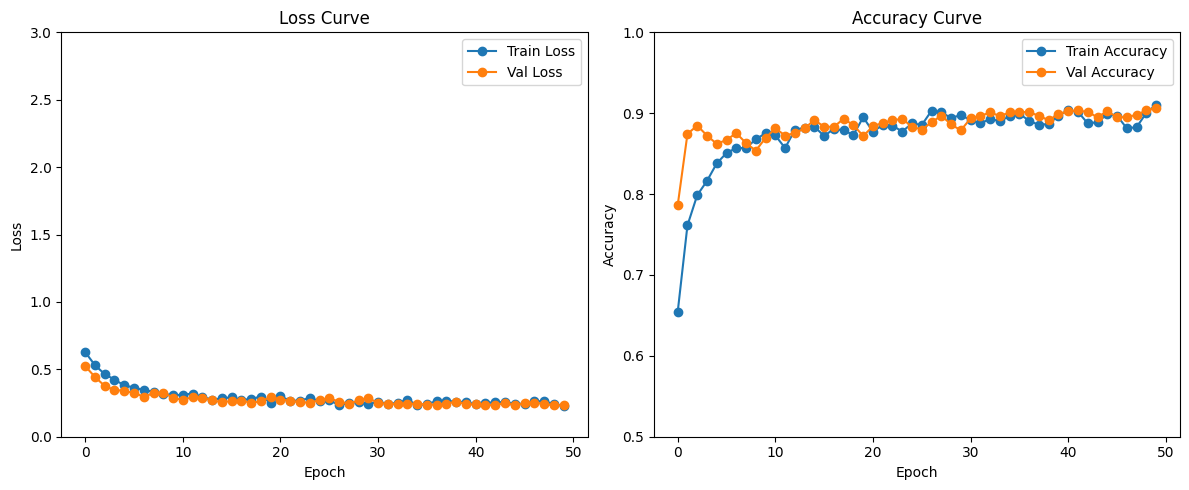

In [ ]:
#Version2
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "/content/drive/MyDrive/Image Processing Lock In Version/Preprocessing/Preprocessing 3 (CLACHE + Sobel)"


# Add Augmentation

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.7),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2))
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_full = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
subset_size = int(0.3 * len(train_full))
subset_idx = random.sample(range(len(train_full)), subset_size)
train_ds = Subset(train_full, subset_idx)

val_ds = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_test_transform)
test_ds = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)


model = models.densenet121(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False  # freeze feature extractor

num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.6),
    nn.Linear(256, 2)
)
model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4, weight_decay=1e-3)


#Training Loop

epochs = 50
train_loss_list, val_loss_list, train_acc_list, val_acc_list = [], [], [], []

for epoch in range(epochs):
    model.train()
    train_loss, train_correct = 0.0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_ds)
    train_acc = train_correct / len(train_ds)

    # Validation
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(val_ds)
    val_acc = val_correct / len(val_ds)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] TrainLoss={train_loss:.4f} ValLoss={val_loss:.4f} "
          f"TrainAcc={train_acc:.4f} ValAcc={val_acc:.4f}")


#Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss_list, marker='o', label="Train Loss")
plt.plot(val_loss_list, marker='o', label="Val Loss")
plt.ylim(0,3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_list, marker='o', label="Train Accuracy")
plt.plot(val_acc_list, marker='o', label="Val Accuracy")
plt.ylim(0.5,1)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()
